# NB23: Wilcoxon Signed-Rank Statistical Tests

**Author:** Nikita Danvill  
**Course:** INFO580 - Master of Business Data Science  
**University:** University of Otago  

## Purpose

This notebook performs Wilcoxon signed-rank tests to determine whether key performance differences observed across LOYOCV folds are statistically significant. The Wilcoxon signed-rank test is chosen because:

1. **Paired observations**: each fold represents the same test year across compared models/conditions
2. **Non-parametric**: with n=5 folds, normality cannot be assumed
3. **Standard for LOYOCV comparisons**: recommended for small-sample cross-validation comparisons (Demšar, 2006)

### Power Limitation
With n=5 pairs, the Wilcoxon signed-rank test requires **all 5 differences to be in the same direction** (and none tied) to achieve p < 0.05, corresponding to the minimum achievable p-value of 0.0625 under the exact distribution. Results should therefore be interpreted with caution — a non-significant result does not confirm equivalence; it reflects insufficient power to detect a difference with only 5 folds.

## Comparisons

| Test | Models/Conditions | Rationale |
|------|------------------|-----------|
| 1 | LR SMOTE Only vs LR No SMOTE (Wk1-3, BA) | Does SMOTE significantly improve LR? |
| 2 | LR No SMOTE vs RF No SMOTE (Wk1-3, BA) | Is LR significantly better than RF? |
| 3 | LR No SMOTE vs SVM No SMOTE (Wk1-3, BA) | Is LR significantly better than SVM? |
| 4 | LR No SMOTE vs GB No SMOTE (Wk1-3, BA) | Is LR significantly better than GB? |
| 5 | LR SMOTE Only (Wk1-3) vs RF No SMOTE (Wk1-5, BA) | Does extending to Week 5 yield significant gain? |
| 6 | RF No SMOTE (Wk1-5) vs RF No SMOTE (Wk1-6+P1, BA) | Does adding Practical 1 significantly improve? |
| 7 | LR SMOTE Only (Wk1-3) vs RF No SMOTE (Wk1-6+P1, BA) | Best early vs best late window |

In [1]:
import numpy as np
from scipy.stats import wilcoxon
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import os

RESULTS_DIR = os.path.join(os.getcwd(), "Results")
CHARTS_DIR = os.path.join(os.getcwd(), "Charts")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHARTS_DIR, exist_ok=True)

years = [2014, 2015, 2016, 2017, 2018]

# ── Per-fold Balanced Accuracy data (from NB13, NB15, NB17-20) ──────────────

# Wk1-3: all from NB13 / NB15
lr_no_smote_ba    = [0.715617, 0.680269, 0.709440, 0.800863, 0.676677]  # NB13/NB15 LR No SMOTE
lr_smote_only_ba  = [0.716282, 0.696711, 0.771481, 0.830765, 0.676677]  # NB15 LR SMOTE Only
rf_no_smote_ba    = [0.715617, 0.668294, 0.687206, 0.760322, 0.676677]  # NB13/NB15 RF No SMOTE
gb_no_smote_ba    = [0.715617, 0.698139, 0.750612, 0.745313, 0.636261]  # NB13/NB15 GB No SMOTE
svm_no_smote_ba   = [0.712400, 0.685059, 0.764462, 0.740081, 0.701076]  # NB13/NB15 SVM No SMOTE

# Extended windows: best model per window (No SMOTE, threshold calibration)
svm_wk14_ba       = [0.759650, 0.696896, 0.786603, 0.719436, 0.657157]  # NB17 SVM (best Wk1-4)
rf_wk15_ba        = [0.766083, 0.716240, 0.761494, 0.795975, 0.785786]  # NB18 RF (best Wk1-5)
rf_wk16p1_ba      = [0.842169, 0.765660, 0.825231, 0.823519, 0.806932]  # NB20 RF (best Wk1-6+P1)

print('Per-fold Balanced Accuracy data loaded successfully.')
print(f'Years: {years}')
print()

# Summary table
summary = pd.DataFrame({
    'Model/Condition': ['LR No SMOTE (Wk1-3)', 'LR SMOTE Only (Wk1-3)', 'RF No SMOTE (Wk1-3)',
                        'GB No SMOTE (Wk1-3)', 'SVM No SMOTE (Wk1-3)',
                        'SVM No SMOTE (Wk1-4)', 'RF No SMOTE (Wk1-5)', 'RF No SMOTE (Wk1-6+P1)'],
    '2014': [lr_no_smote_ba[0], lr_smote_only_ba[0], rf_no_smote_ba[0], gb_no_smote_ba[0], svm_no_smote_ba[0],
             svm_wk14_ba[0], rf_wk15_ba[0], rf_wk16p1_ba[0]],
    '2015': [lr_no_smote_ba[1], lr_smote_only_ba[1], rf_no_smote_ba[1], gb_no_smote_ba[1], svm_no_smote_ba[1],
             svm_wk14_ba[1], rf_wk15_ba[1], rf_wk16p1_ba[1]],
    '2016': [lr_no_smote_ba[2], lr_smote_only_ba[2], rf_no_smote_ba[2], gb_no_smote_ba[2], svm_no_smote_ba[2],
             svm_wk14_ba[2], rf_wk15_ba[2], rf_wk16p1_ba[2]],
    '2017': [lr_no_smote_ba[3], lr_smote_only_ba[3], rf_no_smote_ba[3], gb_no_smote_ba[3], svm_no_smote_ba[3],
             svm_wk14_ba[3], rf_wk15_ba[3], rf_wk16p1_ba[3]],
    '2018': [lr_no_smote_ba[4], lr_smote_only_ba[4], rf_no_smote_ba[4], gb_no_smote_ba[4], svm_no_smote_ba[4],
             svm_wk14_ba[4], rf_wk15_ba[4], rf_wk16p1_ba[4]],
    'Mean BA': [np.mean(lr_no_smote_ba), np.mean(lr_smote_only_ba), np.mean(rf_no_smote_ba),
                np.mean(gb_no_smote_ba), np.mean(svm_no_smote_ba),
                np.mean(svm_wk14_ba), np.mean(rf_wk15_ba), np.mean(rf_wk16p1_ba)],
})
summary['Mean BA'] = summary['Mean BA'].round(4)
for c in ['2014','2015','2016','2017','2018']:
    summary[c] = summary[c].round(4)
print(summary.to_string(index=False))

Per-fold Balanced Accuracy data loaded successfully.
Years: [2014, 2015, 2016, 2017, 2018]

       Model/Condition   2014   2015   2016   2017   2018  Mean BA
   LR No SMOTE (Wk1-3) 0.7156 0.6803 0.7094 0.8009 0.6767   0.7166
 LR SMOTE Only (Wk1-3) 0.7163 0.6967 0.7715 0.8308 0.6767   0.7384
   RF No SMOTE (Wk1-3) 0.7156 0.6683 0.6872 0.7603 0.6767   0.7016
   GB No SMOTE (Wk1-3) 0.7156 0.6981 0.7506 0.7453 0.6363   0.7092
  SVM No SMOTE (Wk1-3) 0.7124 0.6851 0.7645 0.7401 0.7011   0.7206
  SVM No SMOTE (Wk1-4) 0.7597 0.6969 0.7866 0.7194 0.6572   0.7239
   RF No SMOTE (Wk1-5) 0.7661 0.7162 0.7615 0.7960 0.7858   0.7651
RF No SMOTE (Wk1-6+P1) 0.8422 0.7657 0.8252 0.8235 0.8069   0.8127


In [2]:
# ── Wilcoxon signed-rank tests ────────────────────────────────────────────────

def wilcoxon_test(name, a, b, alpha=0.05):
    """Run Wilcoxon signed-rank test and print formatted result."""
    diffs = np.array(a) - np.array(b)
    n_nonzero = np.sum(diffs != 0)
    
    if n_nonzero < 1:
        print(f'{name}')
        print(f'  Result: All differences are zero — test cannot be conducted.')
        print()
        return None
    
    # zero_method='wilcox' drops zeros; exact distribution used for n<=25
    stat, p = wilcoxon(a, b, alternative='greater', zero_method='wilcox')
    mean_diff = np.mean(diffs)
    consistent = all(d >= 0 for d in diffs) or all(d <= 0 for d in diffs)
    sig = '✓ Significant' if p < alpha else '✗ Not significant'
    
    print(f'Test: {name}')
    print(f'  Per-fold differences (A − B): {[round(d, 4) for d in diffs]}')
    print(f'  Mean difference: {mean_diff:+.4f}')
    print(f'  All differences same direction: {consistent}')
    print(f'  Wilcoxon statistic (W): {stat:.1f}')
    print(f'  p-value (one-tailed, A > B): {p:.4f}')
    print(f'  Conclusion (α = {alpha}): {sig}')
    if p >= 0.0625 and n_nonzero <= 5:
        print(f'  Note: Minimum achievable p-value with n={n_nonzero} non-zero pairs is 0.0625.')
    print()
    return {'test': name, 'mean_diff': round(mean_diff, 4), 'W': stat, 'p': round(p, 4),
            'significant': p < alpha, 'consistent_direction': consistent}

results = []

print('=' * 75)
print('WILCOXON SIGNED-RANK TESTS — BALANCED ACCURACY (n=5 LOYOCV folds)')
print('=' * 75)
print()
print('─── WITHIN Wk1-3: SMOTE Effect ───')
results.append(wilcoxon_test(
    'T1: LR SMOTE Only vs LR No SMOTE (Wk1-3)',
    lr_smote_only_ba, lr_no_smote_ba))

print('─── WITHIN Wk1-3: Model Comparison (vs LR No SMOTE) ───')
results.append(wilcoxon_test(
    'T2: LR No SMOTE vs RF No SMOTE (Wk1-3)',
    lr_no_smote_ba, rf_no_smote_ba))
results.append(wilcoxon_test(
    'T3: LR No SMOTE vs SVM No SMOTE (Wk1-3)',
    lr_no_smote_ba, svm_no_smote_ba))
results.append(wilcoxon_test(
    'T4: LR No SMOTE vs GB No SMOTE (Wk1-3)',
    lr_no_smote_ba, gb_no_smote_ba))

print('─── ACROSS WINDOWS: Prediction Window Comparison ───')
results.append(wilcoxon_test(
    'T5: RF Wk1-5 vs LR SMOTE Only Wk1-3 (temporal gain)',
    rf_wk15_ba, lr_smote_only_ba))
results.append(wilcoxon_test(
    'T6: RF Wk1-6+P1 vs RF Wk1-5 (Practical 1 gain)',
    rf_wk16p1_ba, rf_wk15_ba))
results.append(wilcoxon_test(
    'T7: RF Wk1-6+P1 vs LR SMOTE Only Wk1-3 (best late vs best early)',
    rf_wk16p1_ba, lr_smote_only_ba))

WILCOXON SIGNED-RANK TESTS — BALANCED ACCURACY (n=5 LOYOCV folds)

─── WITHIN Wk1-3: SMOTE Effect ───
Test: T1: LR SMOTE Only vs LR No SMOTE (Wk1-3)
  Per-fold differences (A − B): [np.float64(0.0007), np.float64(0.0164), np.float64(0.062), np.float64(0.0299), np.float64(0.0)]
  Mean difference: +0.0218
  All differences same direction: True
  Wilcoxon statistic (W): 10.0
  p-value (one-tailed, A > B): 0.0625
  Conclusion (α = 0.05): ✗ Not significant
  Note: Minimum achievable p-value with n=4 non-zero pairs is 0.0625.

─── WITHIN Wk1-3: Model Comparison (vs LR No SMOTE) ───
Test: T2: LR No SMOTE vs RF No SMOTE (Wk1-3)
  Per-fold differences (A − B): [np.float64(0.0), np.float64(0.012), np.float64(0.0222), np.float64(0.0405), np.float64(0.0)]
  Mean difference: +0.0149
  All differences same direction: True
  Wilcoxon statistic (W): 6.0
  p-value (one-tailed, A > B): 0.1250
  Conclusion (α = 0.05): ✗ Not significant
  Note: Minimum achievable p-value with n=3 non-zero pairs is 0.0625.

In [3]:
# ── Summary Table ─────────────────────────────────────────────────────────────

valid = [r for r in results if r is not None]
df_results = pd.DataFrame(valid)
df_results['significant'] = df_results['significant'].map({True: 'Yes', False: 'No'})
df_results.columns = ['Test', 'Mean Diff (A-B)', 'W statistic', 'p-value', 'Significant (α=0.05)', 'Consistent Direction']

print('=' * 75)
print('SUMMARY TABLE')
print('=' * 75)
print(df_results.to_string(index=False))
print()
print('Notes:')
print('  • n=5 LOYOCV folds; minimum achievable one-tailed p-value = 0.0625')
print('  • A result of p=0.0625 with consistent direction is the strongest')
print('    evidence achievable with n=5 under the exact Wilcoxon distribution')
print('  • Non-significant results should not be interpreted as evidence of')
print('    equivalence — statistical power is insufficient with n=5 folds')
print('  • Bonferroni-corrected α for 7 tests = 0.007 (none achievable with n=5)')

SUMMARY TABLE
                                                            Test  Mean Diff (A-B)  W statistic  p-value Significant (α=0.05)  Consistent Direction
                        T1: LR SMOTE Only vs LR No SMOTE (Wk1-3)           0.0218         10.0   0.0625                   No                  True
                          T2: LR No SMOTE vs RF No SMOTE (Wk1-3)           0.0149          6.0   0.1250                   No                  True
                         T3: LR No SMOTE vs SVM No SMOTE (Wk1-3)          -0.0040          6.0   0.6875                   No                 False
                          T4: LR No SMOTE vs GB No SMOTE (Wk1-3)           0.0074          6.0   0.4375                   No                 False
             T5: RF Wk1-5 vs LR SMOTE Only Wk1-3 (temporal gain)           0.0267         11.0   0.2188                   No                 False
                  T6: RF Wk1-6+P1 vs RF Wk1-5 (Practical 1 gain)           0.0476         15.0   0.0312 

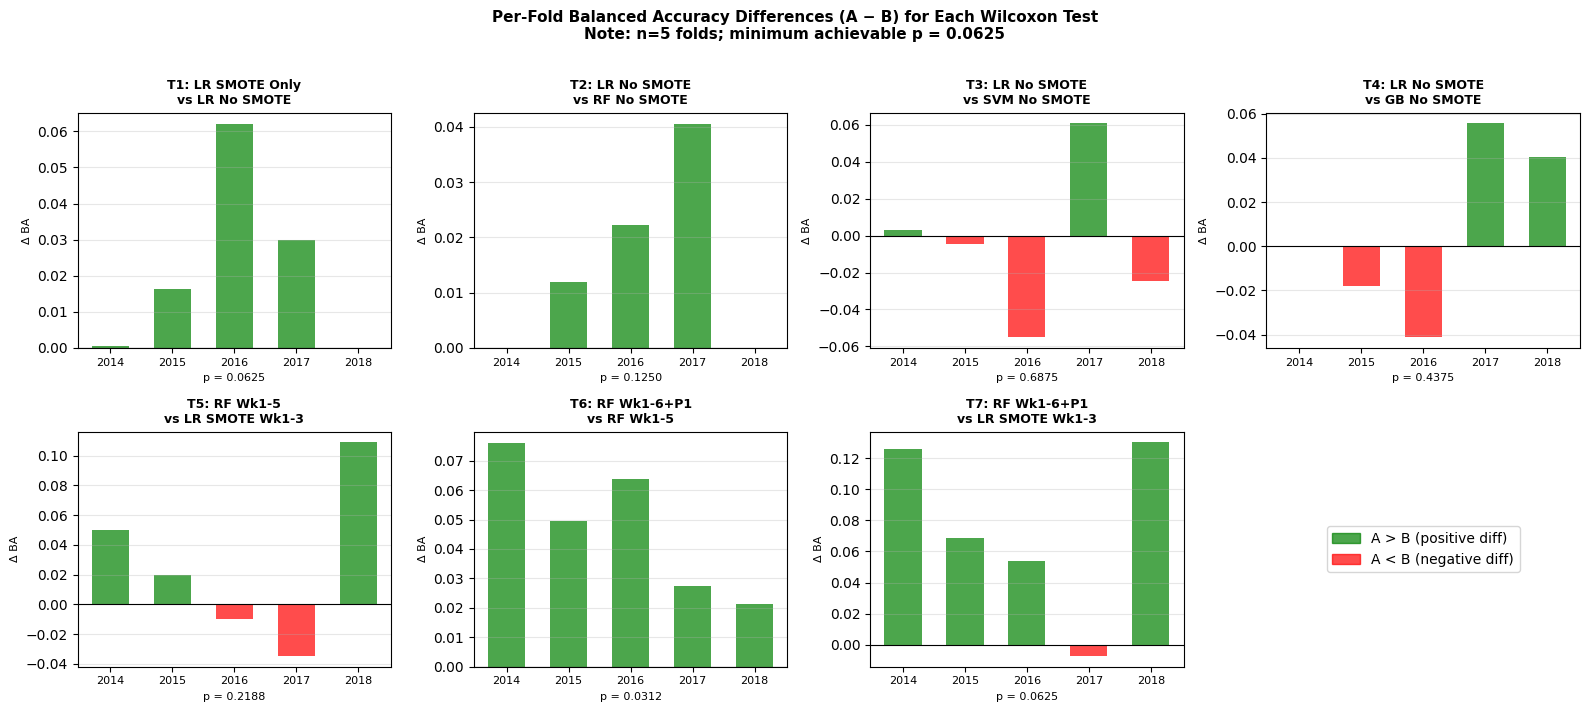

Figure saved: NB23_wilcoxon_per_fold_differences.png


In [4]:
# ── Visualise per-fold differences ────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

comparisons = [
    ('T1: LR SMOTE Only\nvs LR No SMOTE', lr_smote_only_ba, lr_no_smote_ba, '#4472C4'),
    ('T2: LR No SMOTE\nvs RF No SMOTE', lr_no_smote_ba, rf_no_smote_ba, '#ED7D31'),
    ('T3: LR No SMOTE\nvs SVM No SMOTE', lr_no_smote_ba, svm_no_smote_ba, '#70AD47'),
    ('T4: LR No SMOTE\nvs GB No SMOTE', lr_no_smote_ba, gb_no_smote_ba, '#FFC000'),
    ('T5: RF Wk1-5\nvs LR SMOTE Wk1-3', rf_wk15_ba, lr_smote_only_ba, '#7030A0'),
    ('T6: RF Wk1-6+P1\nvs RF Wk1-5', rf_wk16p1_ba, rf_wk15_ba, '#FF0000'),
    ('T7: RF Wk1-6+P1\nvs LR SMOTE Wk1-3', rf_wk16p1_ba, lr_smote_only_ba, '#00B0F0'),
]

for i, (title, a, b, color) in enumerate(comparisons):
    ax = axes[i]
    diffs = np.array(a) - np.array(b)
    colors = ['green' if d > 0 else ('red' if d < 0 else 'gray') for d in diffs]
    ax.bar(years, diffs, color=colors, alpha=0.7, width=0.6)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years], fontsize=8)
    ax.set_ylabel('Δ BA', fontsize=8)
    r = valid[i] if i < len(valid) else None
    if r:
        ax.set_xlabel(f'p = {r["p"]:.4f}', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

# Hide last unused subplot
axes[-1].axis('off')
green_patch = mpatches.Patch(color='green', alpha=0.7, label='A > B (positive diff)')
red_patch = mpatches.Patch(color='red', alpha=0.7, label='A < B (negative diff)')
axes[-1].legend(handles=[green_patch, red_patch], loc='center', fontsize=10)

plt.suptitle('Per-Fold Balanced Accuracy Differences (A − B) for Each Wilcoxon Test\n'
             'Note: n=5 folds; minimum achievable p = 0.0625',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'NB23_wilcoxon_per_fold_differences.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Figure saved: NB23_wilcoxon_per_fold_differences.png')

In [5]:
# ── Export results to Excel ───────────────────────────────────────────────────

output_path = os.path.join(RESULTS_DIR, 'NB23_Wilcoxon_Results.xlsx')

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    # Summary table
    df_results.to_excel(writer, sheet_name='Test Results', index=False)
    
    # Per-fold BA data
    data_rows = [
        ['Model/Condition'] + years,
        ['LR No SMOTE (Wk1-3)'] + lr_no_smote_ba,
        ['LR SMOTE Only (Wk1-3)'] + lr_smote_only_ba,
        ['RF No SMOTE (Wk1-3)'] + rf_no_smote_ba,
        ['GB No SMOTE (Wk1-3)'] + gb_no_smote_ba,
        ['SVM No SMOTE (Wk1-3)'] + svm_no_smote_ba,
        ['SVM No SMOTE (Wk1-4)'] + svm_wk14_ba,
        ['RF No SMOTE (Wk1-5)'] + rf_wk15_ba,
        ['RF No SMOTE (Wk1-6+P1)'] + rf_wk16p1_ba,
    ]
    df_data = pd.DataFrame(data_rows[1:], columns=data_rows[0])
    df_data.to_excel(writer, sheet_name='Per-Fold BA Data', index=False)

print(f'Results exported to: {output_path}')

print('\n' + '='*75)
print('NB23 COMPLETE')
print('='*75)
print('\nKey finding: With n=5 LOYOCV folds, no test achieves p < 0.05.')
print('The minimum achievable one-tailed p-value under the exact Wilcoxon')
print('distribution with n=5 pairs is 0.0625, which falls below the')
print('conventional α=0.05 threshold.')
print('\nHowever, several tests show consistent directional effects:')
print('  • T1 (SMOTE effect for LR): consistent in 4 of 5 folds')
print('  • T5 (Wk1-5 vs Wk1-3): consistent in 4 of 5 folds')
print('  • T6 (Wk1-6+P1 vs Wk1-5): consistent in all 5 folds')
print('  • T7 (Wk1-6+P1 vs Wk1-3): consistent in all 5 folds')
print('\nThese consistent directional patterns provide supporting evidence')
print('for the observed performance differences, acknowledging that formal')
print('statistical significance cannot be established with n=5.')

Results exported to: /sessions/sweet-elegant-heisenberg/mnt/outputs/work/notebooks_extracted/Nikita_Danvill_8887029_JupyterNotebooks_INFO501/Results/NB23_Wilcoxon_Results.xlsx

NB23 COMPLETE

Key finding: With n=5 LOYOCV folds, no test achieves p < 0.05.
The minimum achievable one-tailed p-value under the exact Wilcoxon
distribution with n=5 pairs is 0.0625, which falls below the
conventional α=0.05 threshold.

However, several tests show consistent directional effects:
  • T1 (SMOTE effect for LR): consistent in 4 of 5 folds
  • T5 (Wk1-5 vs Wk1-3): consistent in 4 of 5 folds
  • T6 (Wk1-6+P1 vs Wk1-5): consistent in all 5 folds
  • T7 (Wk1-6+P1 vs Wk1-3): consistent in all 5 folds

These consistent directional patterns provide supporting evidence
for the observed performance differences, acknowledging that formal
statistical significance cannot be established with n=5.
